In [7]:
import pandas as pd

# Load Cluster 3
df = pd.read_csv("C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster_3.csv")

# Show the first few rows to find the review column
df.head()

,customer_unique_id,total_orders,total_spend,avg_order_value,avg_payment_installments,avg_review_score,category_diversity,recency_days,most_common_category,customer_city,customer_state,review_comment_message,total_orders_winsor,total_spend_winsor,avg_order_value_winsor,cluster
0,0005ef4cd20d2893f0d9fbd94d3c0d97,1,129.76,129.76,4.0,1.0,1,169,sports_leisure,sao luis,MA,Até o presente momento não recebi o produto e ...,1,129.76000,129.76,3
1,0012929d977a8d7280bb277c1e5f589d,1,155.65,155.65,1.0,1.0,1,315,watches_gifts,canoas,RS,Muito bom,1,155.65000,155.65,3
2,0019da6aa6bcb27cc32f1249bd12da05,1,87.71,87.71,1.0,1.0,1,199,housewares,limeira,SP,"Sendo um produto de cerâmica, é frágil. Ao des...",1,87.71000,87.71,3
3,0023557a94bef0038066b5d1b3dc763e,1,107.44,107.44,2.0,3.0,1,153,auto,potirendaba,SP,Muito bom,1,107.44000,107.44,3
4,0025795df7a7d077c4c90162fa820085,1,428.16,214.08,3.0,1.0,1,36,stationery,sao paulo,SP,Não um telefone onde podemos falar sobre o deu...,1,410.84875,214.08,3


In [9]:
import pandas as pd
import re

# Load Cluster 3
df = pd.read_csv("cluster_3.csv")

# Choose the review column name
TEXT_COL = "review_comment_message"  # change if your column name is different

# Keep only this column
df = df[[TEXT_COL]].copy()

# Clean: remove URLs + extra spaces
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[TEXT_COL] = df[TEXT_COL].apply(lambda x: re.sub(r"http\S+|www\.\S+", " ", x))
df[TEXT_COL] = df[TEXT_COL].apply(lambda x: re.sub(r"\s+", " ", x).strip())

# Drop empty and duplicate reviews
df = df[df[TEXT_COL] != ""]
df = df.drop_duplicates(subset=[TEXT_COL])

df.head()

,review_comment_message
0,Até o presente momento não recebi o produto e ...
1,Muito bom
2,"Sendo um produto de cerâmica, é frágil. Ao des..."
4,Não um telefone onde podemos falar sobre o deu...
6,entregue corretamente


In [11]:
# Install libraries (only run this once per environment)
!pip install bertopic sentence-transformers umap-learn hdbscan nltk


In [12]:
# ==== 1. Imports ====
import pandas as pd
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# Download NLTK stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
TEXT_COL = df.columns[0]  # since we only kept 1 column

texts = df[TEXT_COL].astype(str).tolist()
print(f"Loaded {len(texts)} reviews")

Loaded 8091 reviews


In [25]:
# ==== 3. Prepare Portuguese stopwords ====
pt_stop = list(set(stopwords.words('portuguese')) | {"pra", "pro", "tá", "aí", "vc", "vcs"})
vectorizer = CountVectorizer(stop_words=pt_stop, ngram_range=(1,2), min_df=5)


In [27]:
# ==== 4. Choose embedding model ====
# Multilingual MiniLM is fast and works well for Portuguese
embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


In [28]:
# ==== 5. Dimensionality reduction + clustering ====
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric="euclidean",
                         cluster_selection_method="eom", prediction_data=True)


In [31]:
# ==== 6. Build and run BERTopic ====
topic_model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=vectorizer,
    representation_model=KeyBERTInspired(),
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)


2025-08-15 17:44:28,936 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/253 [00:00<?, ?it/s]

2025-08-15 17:46:03,800 - BERTopic - Embedding - Completed ✓
2025-08-15 17:46:03,801 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-15 17:46:16,275 - BERTopic - Dimensionality - Completed ✓
2025-08-15 17:46:16,275 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-15 17:46:20,453 - BERTopic - Cluster - Completed ✓
2025-08-15 17:46:20,457 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-08-15 17:46:35,498 - BERTopic - Representation - Completed ✓


In [33]:
# ==== 7. Save outputs ====
OUT_PREFIX = "cluster3"

# Topic overview
topic_model.get_topic_info().to_csv(f"{OUT_PREFIX}_topics_overview.csv", index=False)

# Representative reviews
rep_rows = []
rep_docs = topic_model.get_representative_docs()
for t, docs in rep_docs.items():
    if t == -1:
        continue
    for i, d in enumerate(docs[:3], start=1):
        rep_rows.append({"topic": t, "rank": i, "review_excerpt": d[:300]})
pd.DataFrame(rep_rows).to_csv(f"{OUT_PREFIX}_representative_docs.csv", index=False)

# Topic assignments
pd.DataFrame({"topic": topics}).to_csv(f"{OUT_PREFIX}_doc_topics.csv", index=False)

# Interactive bar chart
fig = topic_model.visualize_barchart(top_n_topics=10)
fig.write_html(f"{OUT_PREFIX}_barchart.html")

print("Saved:")
print(f"- {OUT_PREFIX}_topics_overview.csv")
print(f"- {OUT_PREFIX}_representative_docs.csv")
print(f"- {OUT_PREFIX}_doc_topics.csv")
print(f"- {OUT_PREFIX}_barchart.html")


Saved:
- cluster3_topics_overview.csv
- cluster3_representative_docs.csv
- cluster3_doc_topics.csv
- cluster3_barchart.html


In [35]:
# Show top 10 topics with their keywords
topic_info = topic_model.get_topic_info()
topic_info.head(10)  # shows in notebook


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3255,-1_recebi produto_comprei produto_prazo entreg...,"[recebi produto, comprei produto, prazo entreg...","[Bom dia,gostaria de saber porque meu pedido v..."
1,0,574,0_comprei dois_comprei duas_recebi comprei_pro...,"[comprei dois, comprei duas, recebi comprei, p...",[Comprei dois cobertores e recebi apenas um | ...
2,1,235,1_caixa veio_caixa_produto danificado_embalage...,"[caixa veio, caixa, produto danificado, embala...","[a caixa do produto veio quebrada., Embalagem ..."
3,2,179,2_lojas lannister_nesta loja_nunca compro_loja...,"[lojas lannister, nesta loja, nunca compro, lo...",[Sempre comprei na loja nunca tive problemas.....
4,3,178,3_comprei produto_veio cor_recebi produto_cor,"[comprei produto, veio cor, recebi produto, co...",[Comprei o produto na cor rosa e veio na cor p...
5,4,175,4_solicito_porem_der_pedi,"[solicito, porem, der, pedi, 05, fiz, efetuar,...",[FIZ A COMPRA DE 3 CAIXAS E RECEBI APENAS 2 CA...
6,5,128,5_recebi produto_produto recebi_produto ainda_...,"[recebi produto, produto recebi, produto ainda...","[Não recebi o produto ainda, Eu não recebi o p..."
7,6,119,6_relógio_hora_horário_veio defeito,"[relógio, hora, horário, veio defeito, chegou ...","[O relógio e MUITO maior que parece, não acho ..."
8,7,112,7_cancelamento_cancelar_demora entregar_deixando,"[cancelamento, cancelar, demora entregar, deix...","[Quero o cancelamento., Eu estou tentando canc..."
9,8,112,8_baixa qualidade_qualidade inferior_qualidade...,"[baixa qualidade, qualidade inferior, qualidad...","[Produto de baixa qualidade., Péssima qualidad..."


In [37]:
# Show the first 3 reviews for Topic 0 (change the number to see other topics)
topic_model.get_representative_docs()[0]


['Comprei dois cobertores e recebi apenas um | Comprei dois cobertores e recebi apenas um',
 'comprei dois produtos iguais e recebi apenas um | comprei dois produtos iguais e recebi apenas um',
 'Eu comprei duas unidades do mesmo produto é apenas uma delas foi entregue sendo que na nota fiscal está dizendo que foram os dois produtos entregue | Eu comprei duas unidades do mesmo produto é apenas uma delas foi entregue sendo que na nota fiscal está dizendo que foram os dois produtos entregue']

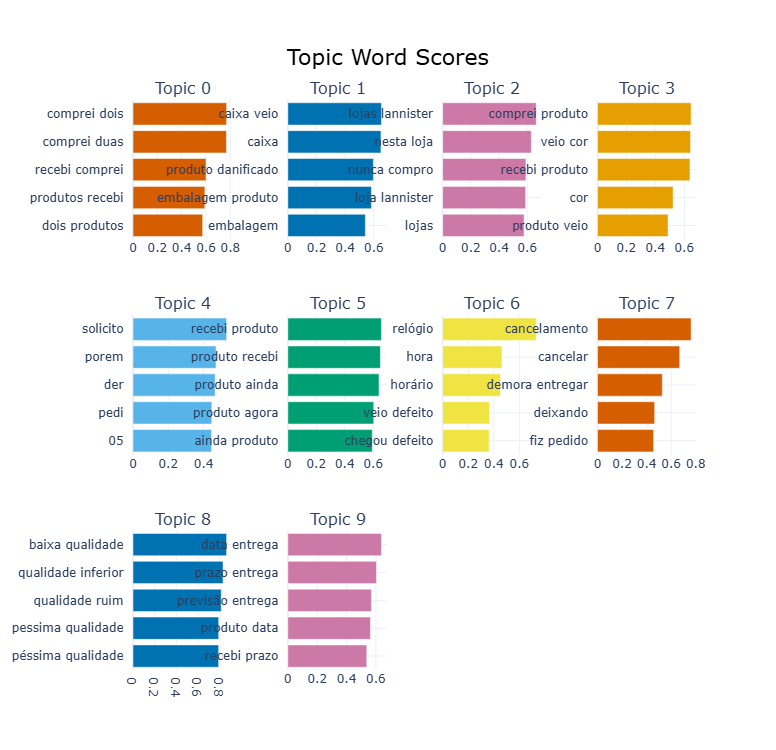

In [39]:
# Show bar chart of top topics directly
topic_model.visualize_barchart(top_n_topics=10)


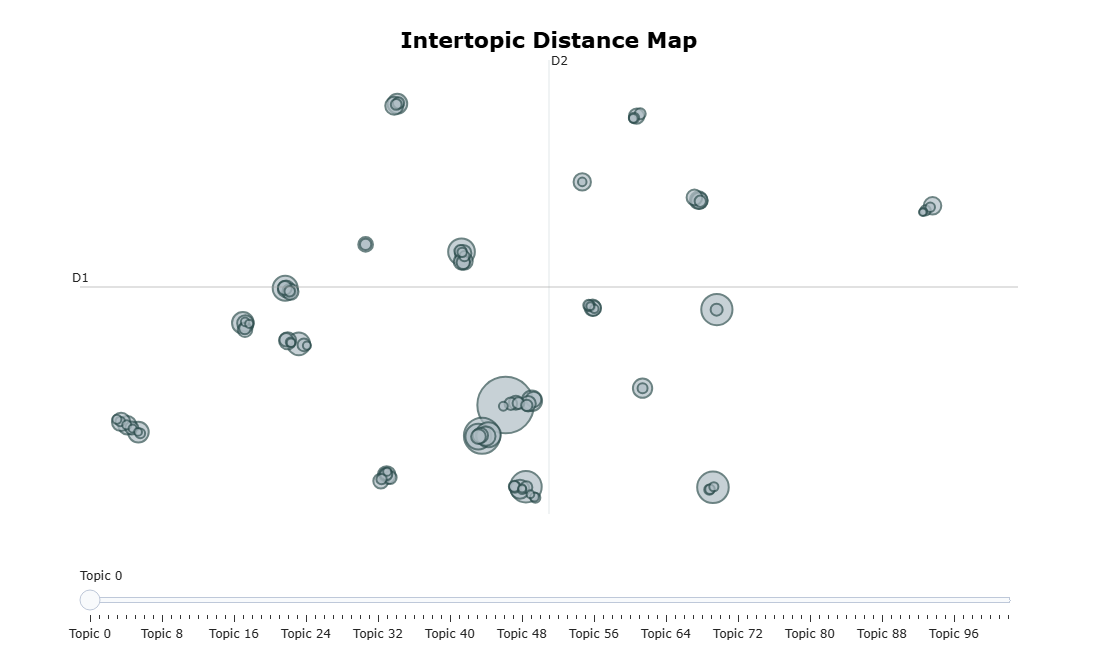

In [41]:
# Show how topics are positioned in semantic space
topic_model.visualize_topics()


In [45]:
!pip install deep-translator wordcloud matplotlib

   ---------------------------------------- 0.0/42.3 kB ? eta -:--:--
   ---------------------------------------- 42.3/42.3 kB 2.0 MB/s eta 0:00:00


In [75]:
import ast  # to convert string representation of list back to Python list
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from itertools import combinations

# Load topic overview
topics_df = pd.read_csv("C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster3_topics_overview.csv")
topics_df = topics_df[topics_df["Topic"] != -1]  # remove outlier

# Convert 'Representation' column from string to list
topics_df["Representation"] = topics_df["Representation"].apply(ast.literal_eval)

# Load embedding model
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def topic_coherence(keywords):
    embeddings = embedder.encode(keywords)
    sims = []
    for w1, w2 in combinations(range(len(embeddings)), 2):
        sim = np.dot(embeddings[w1], embeddings[w2]) / (np.linalg.norm(embeddings[w1]) * np.linalg.norm(embeddings[w2]))
        sims.append(sim)
    return np.mean(sims) if sims else 0

# Calculate semantic coherence
topics_df["Semantic_Coherence"] = topics_df["Representation"].apply(topic_coherence)

# Keyword diversity
all_keywords = [kw for keywords in topics_df["Representation"] for kw in keywords]
unique_keywords = set(all_keywords)
keyword_diversity = len(unique_keywords) / len(all_keywords)

print(f"Keyword Diversity: {keyword_diversity:.3f}")
print(f"Average Semantic Coherence: {topics_df['Semantic_Coherence'].mean():.3f}")

topics_df.to_csv("cluster3_topics_with_metrics.csv", index=False)
topics_df.head(10)


Keyword Diversity: 0.556
Average Semantic Coherence: 0.641


,Topic,Count,Name,Representation,Representative_Docs,Semantic_Coherence
1,0,574,0_comprei dois_comprei duas_recebi comprei_pro...,"[comprei dois, comprei duas, recebi comprei, p...",['Comprei dois cobertores e recebi apenas um |...,0.647428
2,1,235,1_caixa veio_caixa_produto danificado_embalage...,"[caixa veio, caixa, produto danificado, embala...","['a caixa do produto veio quebrada.', 'Embalag...",0.514544
3,2,179,2_lojas lannister_nesta loja_nunca compro_loja...,"[lojas lannister, nesta loja, nunca compro, lo...",['Sempre comprei na loja nunca tive problemas....,0.615080
4,3,178,3_comprei produto_veio cor_recebi produto_cor,"[comprei produto, veio cor, recebi produto, co...",['Comprei o produto na cor rosa e veio na cor ...,0.614627
5,4,175,4_solicito_porem_der_pedi,"[solicito, porem, der, pedi, 05, fiz, efetuar,...",['FIZ A COMPRA DE 3 CAIXAS E RECEBI APENAS 2 C...,0.742607
6,5,128,5_recebi produto_produto recebi_produto ainda_...,"[recebi produto, produto recebi, produto ainda...","['Não recebi o produto ainda', 'Eu não recebi ...",0.679322
7,6,119,6_relógio_hora_horário_veio defeito,"[relógio, hora, horário, veio defeito, chegou ...","['O relógio e MUITO maior que parece, não acho...",0.503425
8,7,112,7_cancelamento_cancelar_demora entregar_deixando,"[cancelamento, cancelar, demora entregar, deix...","['Quero o cancelamento.', 'Eu estou tentando c...",0.627794
9,8,112,8_baixa qualidade_qualidade inferior_qualidade...,"[baixa qualidade, qualidade inferior, qualidad...","['Produto de baixa qualidade.', 'Péssima quali...",0.773357
10,9,92,9_data entrega_prazo entrega_previsão entrega_...,"[data entrega, prazo entrega, previsão entrega...",['Previsão para a entrega do produto até o dia...,0.551083


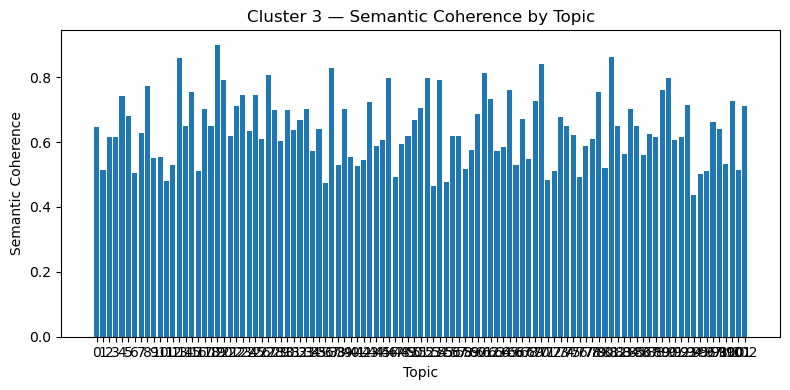

In [73]:
# OPTIONAL: visualize per-topic coherence
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(topics["Topic"].astype(str), topics["Semantic_Coherence"])
plt.xlabel("Topic")
plt.ylabel("Semantic Coherence")
plt.title("Cluster 3 — Semantic Coherence by Topic")
plt.tight_layout()
plt.show()


In [79]:
# Install once if not already done
!pip install wordcloud matplotlib

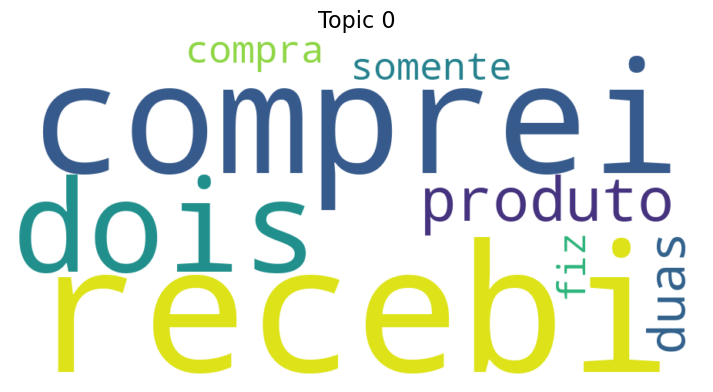

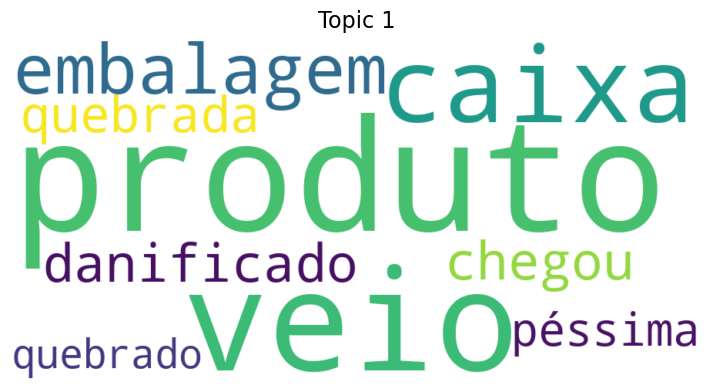

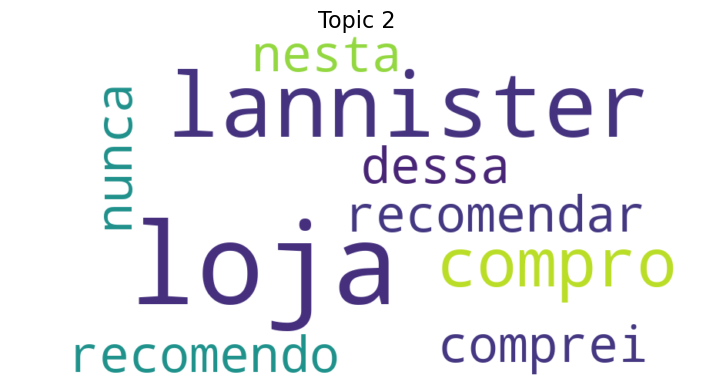

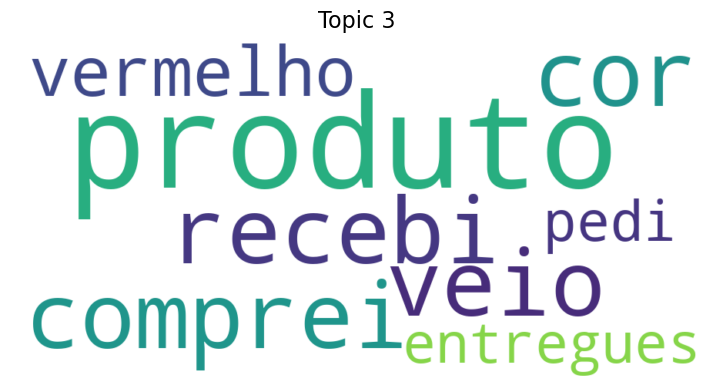

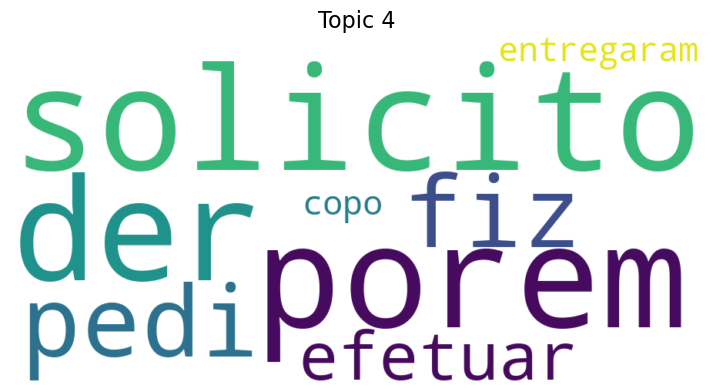

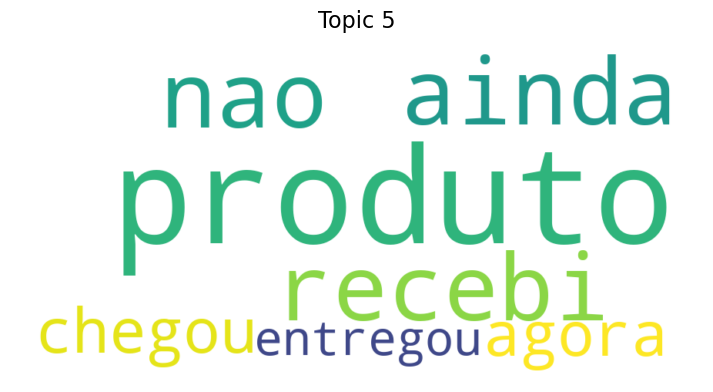

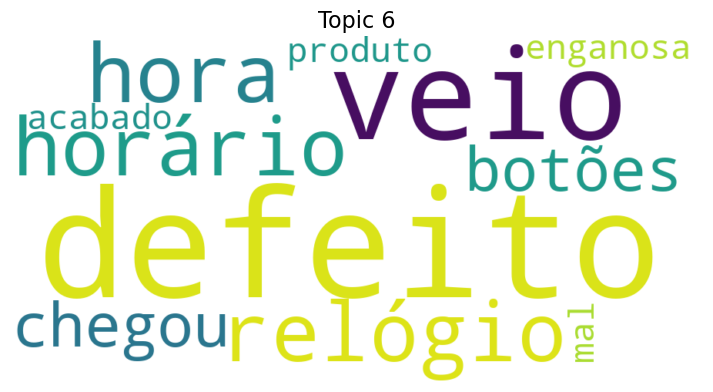

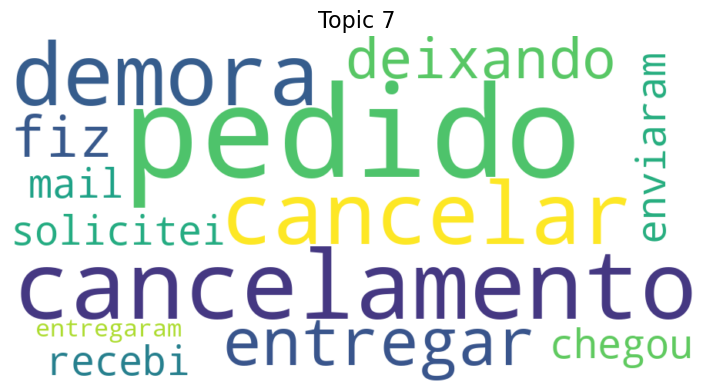

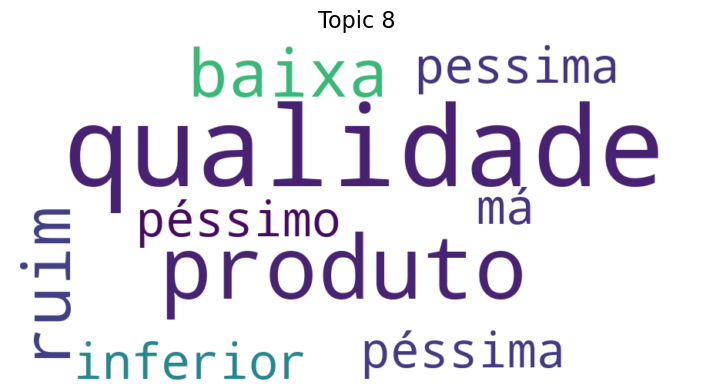

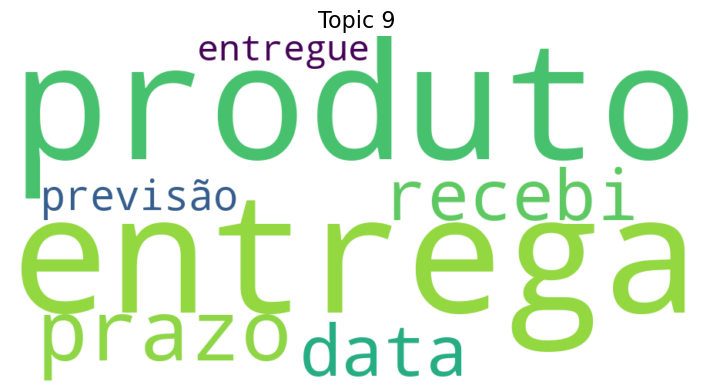

✅ Word clouds saved in: C:\Users\User\OneDrive - University of Exeter\Desktop\Business Project\wordclouds_cluster3


In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import ast
from pathlib import Path

# === 1. Load topics CSV ===
topics_df = pd.read_csv("C:/Users/User/OneDrive - University of Exeter/Desktop/Business Project/cluster3_topics_overview.csv")

# Convert 'Representation' from string to Python list
topics_df["Representation"] = topics_df["Representation"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Remove outlier topic -1 if present
topics_df = topics_df[topics_df["Topic"] != -1].copy()

# === 2. Setup save directory ===
save_dir = Path("wordclouds_cluster3")
save_dir.mkdir(exist_ok=True)

# === 3. Loop for topics 0–9 ===
for topic_id in range(10):
    topic_row = topics_df[topics_df["Topic"] == topic_id]
    if topic_row.empty:
        continue  # skip if topic ID doesn't exist

    keywords = topic_row.iloc[0]["Representation"]
    text_for_wc = " ".join(keywords)

    wc = WordCloud(width=900, height=450, background_color="white").generate(text_for_wc)

    # Show inline
    plt.figure(figsize=(9, 4.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id}", fontsize=16)
    plt.show()

    # Save PNG
    out_path = save_dir / f"topic_{topic_id}_wordcloud.png"
    wc.to_file(str(out_path))

print(f"✅ Word clouds saved in: {save_dir.resolve()}")
